# What causes diffusivities to look so different?

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.path import Path
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cmocean.cm as cmo
import cartopy.crs as ccrs
import gsw
import rioxarray as rxr #load .tif files
import mixsea as mx
import io
import contextlib
import neutral_density as nd

In [2]:
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize']  = 18
plt.rcParams['axes.labelsize']  = 14
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14

# Avoid inline backend tight-bbox cropping with Cartopy + inset axes/colorbars
from IPython import get_ipython
ip = get_ipython()
if ip is not None:
    ip.run_line_magic("config", "InlineBackend.print_figure_kwargs = {'bbox_inches': None}")

## Load Datasets

In [55]:
ds_pbar = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_var.nc')
ds_pbar_grid = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_grid_var.nc')
ds_pbar_grad = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_grad_diff.nc')

In [56]:
ds_pbar_grid = ds_pbar_grid.assign_coords(LON_left = ds_pbar_grad.LON_left,LAT_left = ds_pbar_grad.LAT_left)
ds_pbar_grid = xr.merge([ds_pbar_grid, ds_pbar_grad.drop_vars({'DENSITY'})])

In [57]:
ds_pbar_grid

<xarray.Dataset>
Dimensions:          (PRESSURE_mean: 1001, LON: 120, LAT: 60, LON_left: 120,
                      LAT_left: 60)
Coordinates:
  * PRESSURE_mean    (PRESSURE_mean) int64 0 2 4 6 8 ... 1994 1996 1998 2000
  * LON              (LON) float64 -178.5 -175.5 -172.5 ... 172.5 175.5 178.5
  * LAT              (LAT) float64 -88.5 -85.5 -82.5 -79.5 ... 82.5 85.5 88.5
  * LON_left         (LON_left) float64 -180.0 -177.0 -174.0 ... 174.0 177.0
  * LAT_left         (LAT_left) float64 -90.0 -87.0 -84.0 ... 81.0 84.0 87.0
Data variables: (12/41)
    CT_sort          (PRESSURE_mean, LON, LAT) float64 ...
    SA_sort          (PRESSURE_mean, LON, LAT) float64 ...
    SPICE_sort       (PRESSURE_mean, LON, LAT) float64 ...
    DENSITY          (PRESSURE_mean, LON, LAT) float64 ...
    CT_sort_m        (PRESSURE_mean, LON, LAT) float64 ...
    SA_sort_m        (PRESSURE_mean, LON, LAT) float64 ...
    ...               ...
    dCT_m_dp         (PRESSURE_mean, LON, LAT) float64 ...
    dSA_m_dp         (PRESSURE_mean, LON, LAT) float64 ...
    dSPICE_m_dp      (PRESSURE_mean, LON, LAT) float64 ...
    K_e_CT           (PRESSURE_mean, LON, LAT) float64 ...
    K_e_SA           (PRESSURE_mean, LON, LAT) float64 ...
    K_e_SPICE        (PRESSURE_mean, LON, LAT) float64 ...

## Plot Diffusivities

In [58]:
def add_hist_inset(ax, data_all, data_depth, depth_value, bins, var, step=1):
    """
    Add a compact inset histogram with:
      - black curve for ALL depths
      - colored curve for the depth of this map panel

    Colors:
      200 m  -> red
      1000 m -> green
      1800 m -> blue
    """

    # Depth → color mapping
    depth_colors = {200:  "tab:red", 1000: "tab:green", 1800: "tab:blue",}
    depth_color = depth_colors[depth_value]

    # --- 1. Background opaque box ---
    bg = inset_axes(ax, width="100%", height="100%", bbox_to_anchor=(0.65, 0.65, 0.35, 0.35), bbox_transform=ax.transAxes, loc="upper left", borderpad=0)
    bg.set_facecolor((1, 1, 1, 0.90))
    bg.set_xticks([])
    bg.set_yticks([])
    for spine in bg.spines.values():
        spine.set_visible(False)

    # --- 2. Foreground histogram inset ---
    inset = inset_axes(ax, width="100%", height="100%", bbox_to_anchor=(0.66, 0.82, 0.34, 0.18), bbox_transform=ax.transAxes, loc="upper left", borderpad=0)
    inset.set_facecolor((1, 1, 1, 0.0))

    # --- Histograms (density normalized) ---
    inset.hist(np.log10(data_all[data_all > 0]), bins=bins, density=True, histtype='step', color='black', lw=1)
    inset.hist(np.log10(data_depth[data_depth > 0]), bins=bins, density=True, histtype='step', color=depth_color, lw=1)

    # --- X axis ---
    xticks = np.arange(bins[0], bins[-1], step)
    inset.set_xticks(xticks)
    inset.set_xticklabels([str(x) for x in xticks], fontsize=7)
    inset.set_xlabel(r"$\log_{10}$" + f" {var}", fontsize=8, labelpad=-3)

    # --- Remove y axis ---
    inset.set_yticks([])
    inset.tick_params(axis='y', left=False, right=False)

    # --- Frame ---
    for spine in inset.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.8)

    # --- Inline labels (only two curves now) ---
    ymin, ymax = inset.get_ylim()
    x_left = bins[0] - 0.02 * (bins[-1] - bins[0])

    inset.text(x_left, ymin + 0.80*(ymax - ymin), "all", color='black', fontsize=7, ha='left', va='center')

    inset.text(x_left, ymin + 0.45*(ymax - ymin), f"{depth_value} m", color=depth_color, fontsize=7, ha='left', va='center')

    return inset

depth: 1800 m


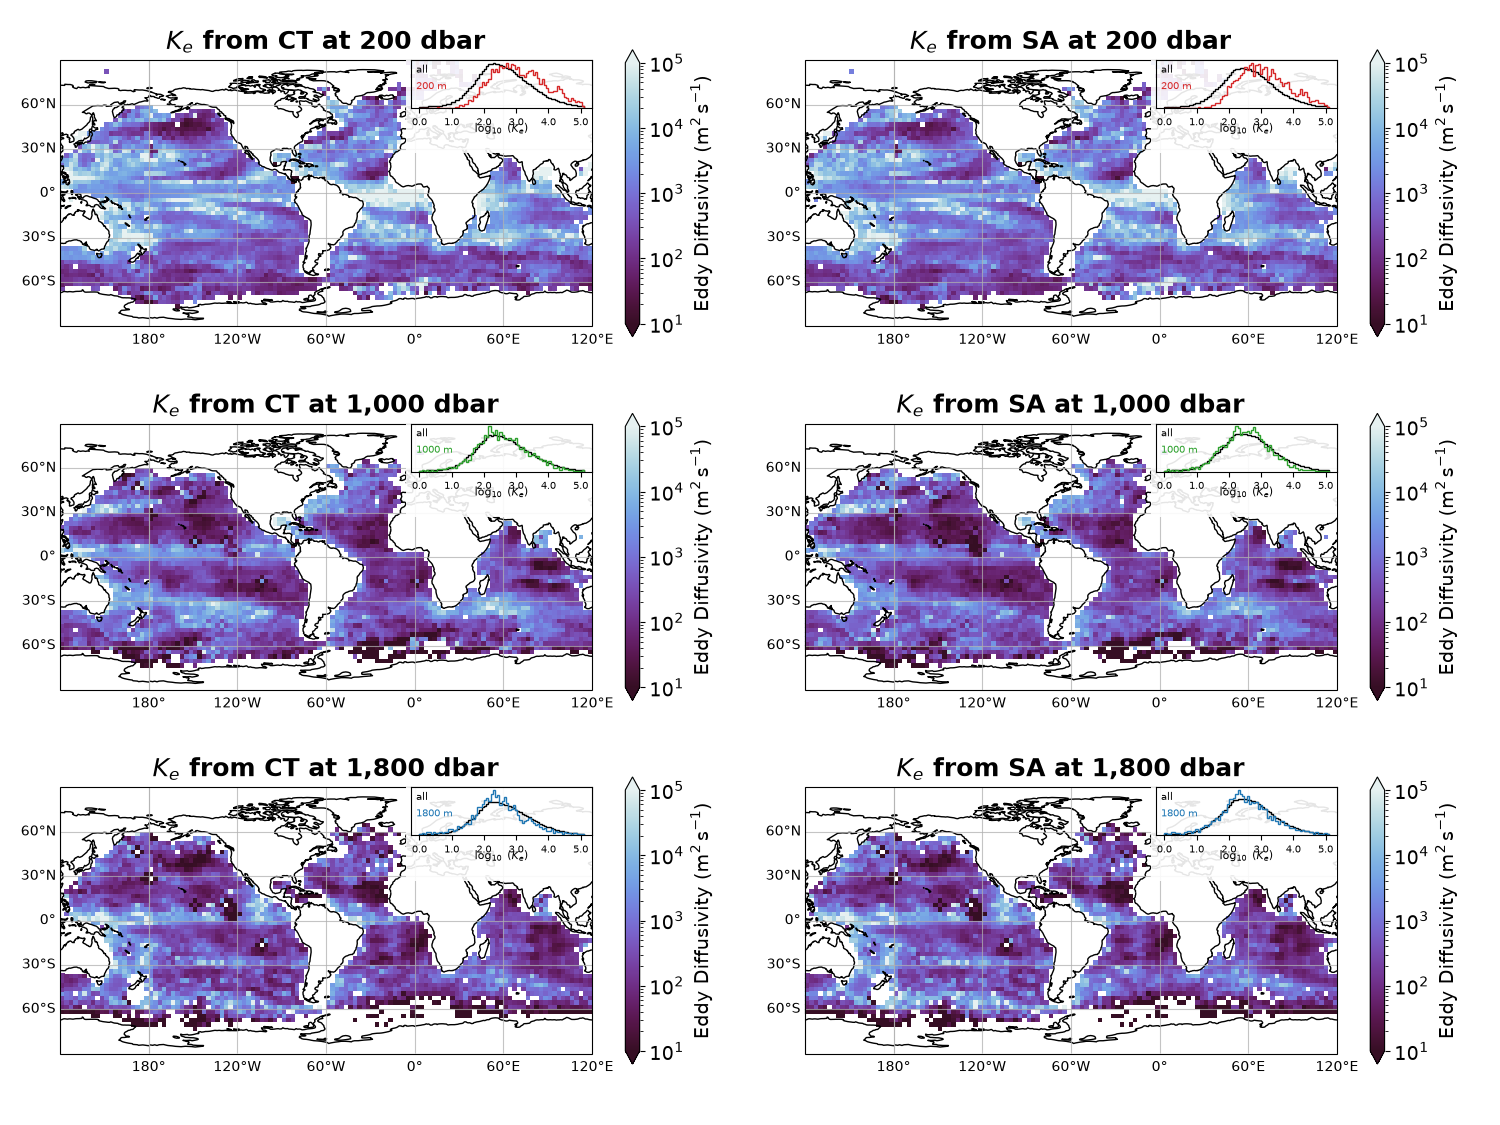

In [59]:
shrink, pad = 0.9, 0.05

# --- Configuration for each subplot ---
fields = [
    ("K_e_CT", 200, cmo.dense_r, (1e1, 1e5),  "log", r"$\mathrm{Eddy\ Diffusivity\ (m^2\,s^{-1})}$", r"$\boldsymbol{K_e}$ from CT at 200 dbar"),
    ("K_e_SA", 200, cmo.dense_r, (1e1, 1e5), "log", r"$\mathrm{Eddy\ Diffusivity\ (m^2\,s^{-1})}$", r"$\boldsymbol{K_e}$ from SA at 200 dbar"),
    ("K_e_CT", 1000, cmo.dense_r, (1e1, 1e5),  "log", r"$\mathrm{Eddy\ Diffusivity\ (m^2\,s^{-1})}$", r"$\boldsymbol{K_e}$ from CT at 1,000 dbar"),
    ("K_e_SA", 1000, cmo.dense_r, (1e1, 1e5), "log", r"$\mathrm{Eddy\ Diffusivity\ (m^2\,s^{-1})}$", r"$\boldsymbol{K_e}$ from SA at 1,000 dbar"),
    ("K_e_CT", 1800, cmo.dense_r, (1e1, 1e5), "log", r"$\mathrm{Eddy\ Diffusivity\ (m^2\,s^{-1})}$", r"$\boldsymbol{K_e}$ from CT at 1,800 dbar"),
    ("K_e_SA", 1800, cmo.dense_r, (1e1, 1e5), "log", r"$\mathrm{Eddy\ Diffusivity\ (m^2\,s^{-1})}$", r"$\boldsymbol{K_e}$ from SA at 1,800 dbar"),
]

# --- Helper function to plot each panel ---
def plot_panel(ax, varname, depth, cmap, vlims, norm_type, cbar_label, title):
    da = ds_pbar_grid[varname].sel(PRESSURE_mean=depth, method='nearest')

    # Choose the correct normalization
    if norm_type == "log":
        norm = colors.LogNorm(vmin=vlims[0], vmax=vlims[1])
    else:
        norm = colors.Normalize(vmin=vlims[0], vmax=vlims[1])

    da.plot(x='LON', y='LAT', cmap=cmap, norm=norm, transform=ccrs.PlateCarree(), ax=ax, cbar_kwargs={'shrink': shrink, 'pad': pad, 'label': cbar_label})

    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, alpha=0.75)
    gl.top_labels, gl.right_labels = False, False

    # Use explicit text title to avoid Cartopy title placement conflicts
    ax.text(
        0.5, 1.02, title, transform=ax.transAxes, ha='center', va='bottom',
        fontsize=plt.rcParams['axes.titlesize'],
        fontweight=plt.rcParams['axes.titleweight'],
        zorder=20
    )

# Precompute bins
bins = np.linspace(0, 5.1, 75)

# Flattened arrays
all_CT    = ds_pbar_grid.K_e_CT.values.flatten()
all_SA    = ds_pbar_grid.K_e_SA.values.flatten()

Ke200_CT  = ds_pbar_grid.K_e_CT.sel(PRESSURE_mean=200,  method='nearest').values.flatten()
Ke1000_CT = ds_pbar_grid.K_e_CT.sel(PRESSURE_mean=1000, method='nearest').values.flatten()
Ke1800_CT = ds_pbar_grid.K_e_CT.sel(PRESSURE_mean=1800, method='nearest').values.flatten()

Ke200_SA  = ds_pbar_grid.K_e_SA.sel(PRESSURE_mean=200,  method='nearest').values.flatten()
Ke1000_SA = ds_pbar_grid.K_e_SA.sel(PRESSURE_mean=1000, method='nearest').values.flatten()
Ke1800_SA = ds_pbar_grid.K_e_SA.sel(PRESSURE_mean=1800, method='nearest').values.flatten()

fig, axes = plt.subplots(3, 2, figsize=(15, 11.25), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=-60)})
axes = axes.ravel()

for i, ax in enumerate(axes):
    var, depth, cmap, vlims, norm_type, cbar_label, title = fields[i]
    plot_panel(ax, var, depth, cmap, vlims, norm_type, cbar_label, title)

    # --- Select the correct depth-specific array ---
    if var == "K_e_CT":
        depth_array = {200: Ke200_CT, 1000: Ke1000_CT, 1800: Ke1800_CT}[depth]
        add_hist_inset(ax, all_CT, depth_array, depth, bins, '$(K_e)$')

    else:  # K_e_SA
        depth_array = {200: Ke200_SA, 1000: Ke1000_SA, 1800: Ke1800_SA}[depth]
        add_hist_inset(ax, all_SA, depth_array, depth, bins, '$(K_e)$')

plt.subplots_adjust(left=0.04, right=0.98, bottom=0.04, top=0.97, wspace=0.12, hspace=0.14)
# Save without bbox_inches='tight' to prevent clipping of geospatial subplots
#plt.savefig(f"quals_paper/results/5_{ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data}.png", dpi=300)
print(f"depth: {ds_pbar_grid.sel(PRESSURE_mean=depth, method='nearest').PRESSURE_mean.data} m")
plt.show()

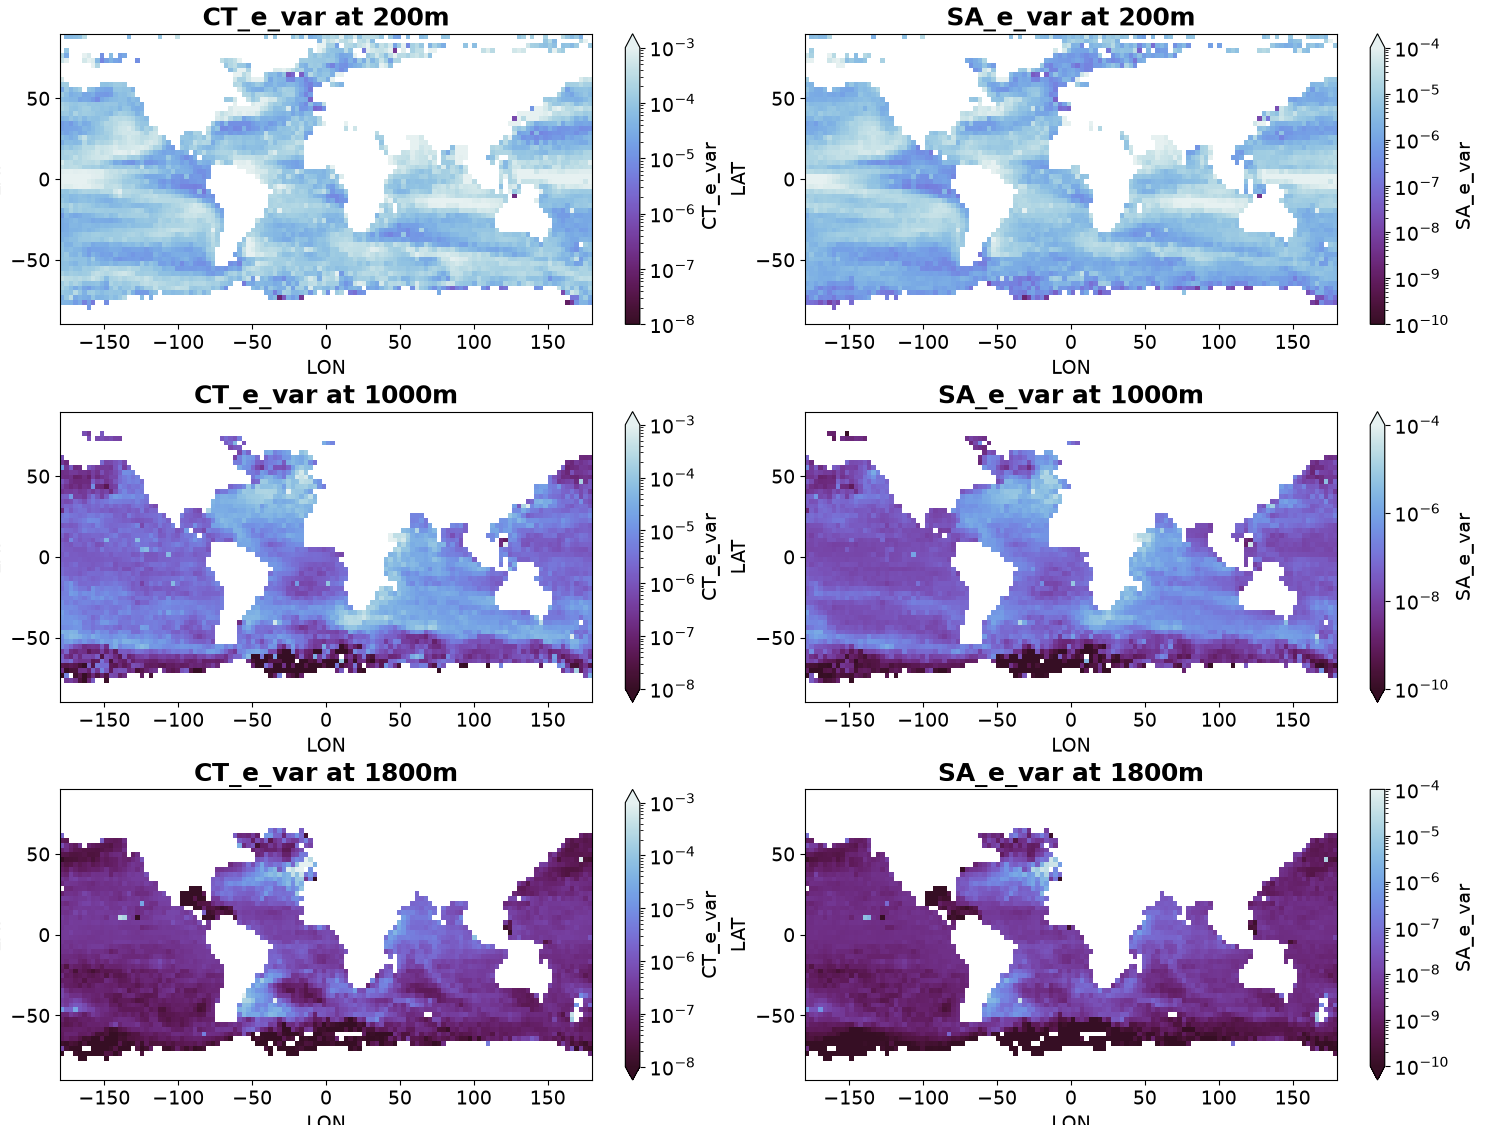

In [60]:
plt.figure(figsize=(15, 11.25))
d1, d2, d3 = 200, 1000, 1800

CT_vmin, CT_vmax = 1e-8, 1e-3
CT_norm = colors.LogNorm(vmin=float(CT_vmin), vmax=float(CT_vmax))
SA_vmin, SA_vmax = 1e-10, 1e-4
SA_norm = colors.LogNorm(vmin=float(SA_vmin), vmax=float(SA_vmax))

CT_var, CT_title = ds_pbar_grid.CT_e_var, 'CT_e_var'
SA_var, SA_title = ds_pbar_grid.SA_e_var, 'SA_e_var'

plt.subplot(321)
CT_var.sel(PRESSURE_mean=d1, method='nearest').plot(
    x='LON', y='LAT', norm=CT_norm, cmap=cmo.dense_r,
    cbar_kwargs={'label': CT_title}
)
plt.title('{} at {}m'.format(CT_title, d1))

plt.subplot(322)
SA_var.sel(PRESSURE_mean=d1, method='nearest').plot(
    x='LON', y='LAT', norm=SA_norm, cmap=cmo.dense_r,
    cbar_kwargs={'label': SA_title}
)
plt.title('{} at {}m'.format(SA_title, d1))

plt.subplot(323)
CT_var.sel(PRESSURE_mean=d2, method='nearest').plot(
    x='LON', y='LAT', norm=CT_norm, cmap=cmo.dense_r,
    cbar_kwargs={'label': CT_title}
)
plt.title('{} at {}m'.format(CT_title, d2))

plt.subplot(324)
SA_var.sel(PRESSURE_mean=d2, method='nearest').plot(
    x='LON', y='LAT', norm=SA_norm, cmap=cmo.dense_r,
    cbar_kwargs={'label': SA_title}
)
plt.title('{} at {}m'.format(SA_title, d2))

plt.subplot(325)
CT_var.sel(PRESSURE_mean=d3, method='nearest').plot(
    x='LON', y='LAT', norm=CT_norm, cmap=cmo.dense_r,
    cbar_kwargs={'label': CT_title}
)
plt.title('{} at {}m'.format(CT_title, d3))

plt.subplot(326)
SA_var.sel(PRESSURE_mean=d3, method='nearest').plot(
    x='LON', y='LAT', norm=SA_norm, cmap=cmo.dense_r,
    cbar_kwargs={'label': SA_title}
)
plt.title('{} at {}m'.format(SA_title, d3))

plt.subplots_adjust(left=0.04, right=0.98, bottom=0.04, top=0.97, wspace=0.12, hspace=0.3)
plt.show()

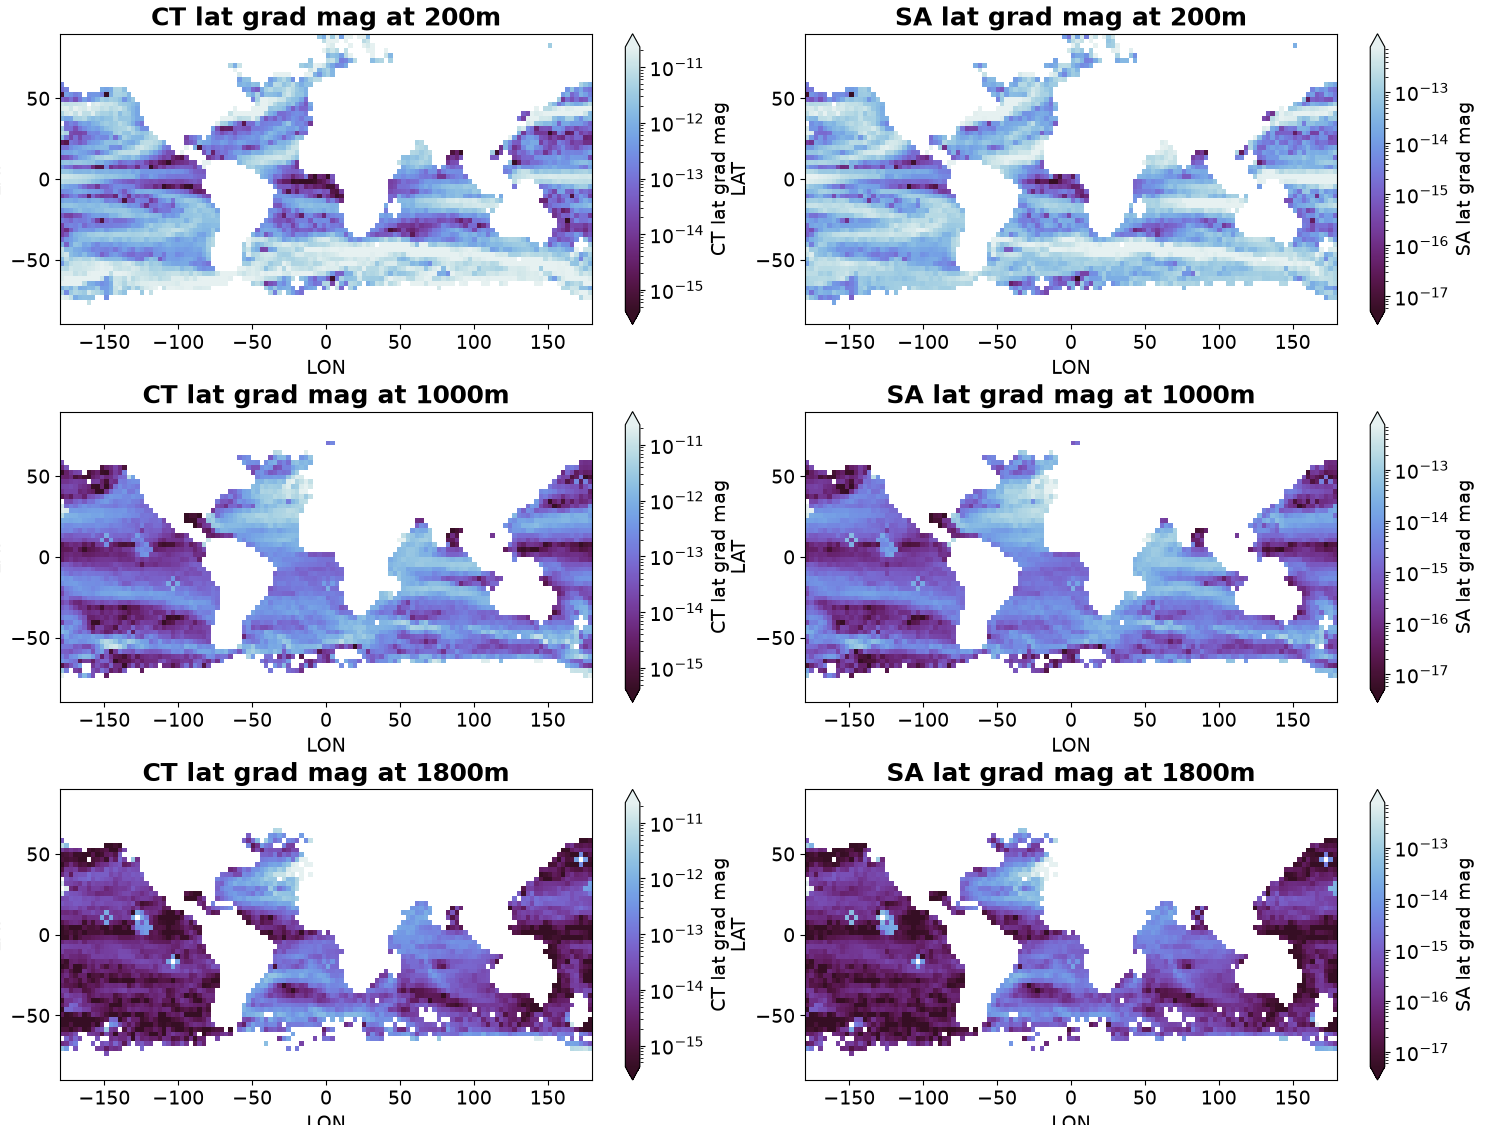

In [61]:
plt.figure(figsize=(15, 11.25))
d1, d2, d3 = 200, 1000, 1800

CT_vmin, CT_vmax = 1e-15, 1e-10
CT_norm = colors.LogNorm(vmin=float(CT_vmin), vmax=float(CT_vmax))
SA_vmin, SA_vmax = 1e-17, 1e-12
SA_norm = colors.LogNorm(vmin=float(SA_vmin), vmax=float(SA_vmax))

CT_var, CT_title = ds_pbar_grid.dCT_m_dx**2 + ds_pbar_grid.dCT_m_dy**2, 'CT lat grad mag'
SA_var, SA_title = ds_pbar_grid.dSA_m_dx**2 + ds_pbar_grid.dSA_m_dy**2, 'SA lat grad mag'

plt.subplot(321)
CT_var.sel(PRESSURE_mean=d1, method='nearest').plot(
    x='LON', y='LAT', norm=ct_norm, cmap=cmo.dense_r,
    cbar_kwargs={'label': CT_title}
)
plt.title('{} at {}m'.format(CT_title, d1))

plt.subplot(322)
SA_var.sel(PRESSURE_mean=d1, method='nearest').plot(
    x='LON', y='LAT', norm=sa_norm, cmap=cmo.dense_r,
    cbar_kwargs={'label': SA_title}
)
plt.title('{} at {}m'.format(SA_title, d1))

plt.subplot(323)
CT_var.sel(PRESSURE_mean=d2, method='nearest').plot(
    x='LON', y='LAT', norm=ct_norm, cmap=cmo.dense_r,
    cbar_kwargs={'label': CT_title}
)
plt.title('{} at {}m'.format(CT_title, d2))

plt.subplot(324)
SA_var.sel(PRESSURE_mean=d2, method='nearest').plot(
    x='LON', y='LAT', norm=sa_norm, cmap=cmo.dense_r,
    cbar_kwargs={'label': SA_title}
)
plt.title('{} at {}m'.format(SA_title, d2))

plt.subplot(325)
CT_var.sel(PRESSURE_mean=d3, method='nearest').plot(
    x='LON', y='LAT', norm=ct_norm, cmap=cmo.dense_r,
    cbar_kwargs={'label': CT_title}
)
plt.title('{} at {}m'.format(CT_title, d3))

plt.subplot(326)
SA_var.sel(PRESSURE_mean=d3, method='nearest').plot(
    x='LON', y='LAT', norm=sa_norm, cmap=cmo.dense_r,
    cbar_kwargs={'label': SA_title}
)
plt.title('{} at {}m'.format(SA_title, d3))

plt.subplots_adjust(left=0.04, right=0.98, bottom=0.04, top=0.97, wspace=0.12, hspace=0.3)
plt.show()

In [62]:
K_rho_p = xr.open_dataarray('/swot/SUM05/amf2288/K_rho_filt_p.nc').drop_vars('Z').rename({'PRESSURE':'PRESSURE_mean'})
K_rho_p = K_rho_p.bfill(dim='PRESSURE_mean').ffill(dim='PRESSURE_mean')

In [63]:
Ke_CT = K_rho_p * ds_pbar_grid.CT_e_var / (ds_pbar_grid.dCT_m_dx**2 + ds_pbar_grid.dCT_m_dy**2)
Ke_SA = K_rho_p * ds_pbar_grid.SA_e_var / (ds_pbar_grid.dSA_m_dx**2 + ds_pbar_grid.dSA_m_dy**2)

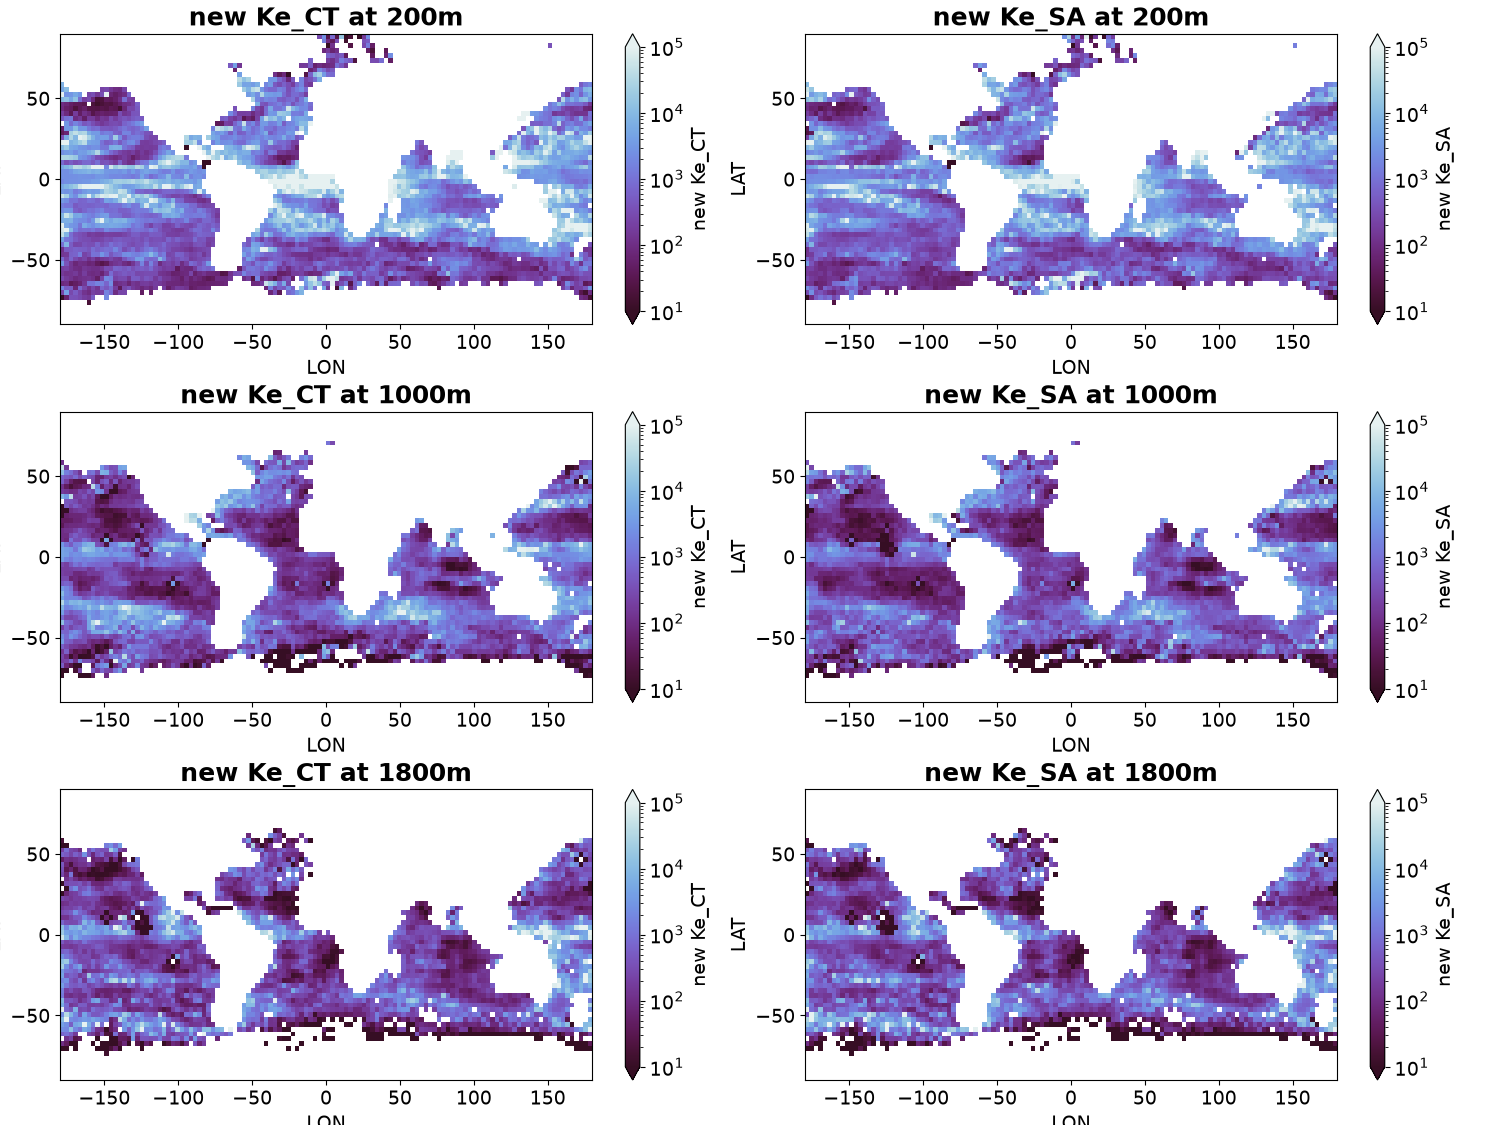

In [64]:
plt.figure(figsize=(15, 11.25))
d1, d2, d3 = 200, 1000, 1800

CT_vmin, CT_vmax = 1e1, 1e5
CT_norm = colors.LogNorm(vmin=float(CT_vmin), vmax=float(CT_vmax))
SA_vmin, SA_vmax = 1e1, 1e5
SA_norm = colors.LogNorm(vmin=float(SA_vmin), vmax=float(SA_vmax))

CT_var, CT_title = Ke_CT, 'new Ke_CT'
SA_var, SA_title = Ke_SA, 'new Ke_SA'

plt.subplot(321)
CT_var.sel(PRESSURE_mean=d1, method='nearest').plot(
    x='LON', y='LAT', norm=CT_norm, cmap=cmo.dense_r,
    cbar_kwargs={'label': CT_title}
)
plt.title('{} at {}m'.format(CT_title, d1))

plt.subplot(322)
SA_var.sel(PRESSURE_mean=d1, method='nearest').plot(
    x='LON', y='LAT', norm=SA_norm, cmap=cmo.dense_r,
    cbar_kwargs={'label': SA_title}
)
plt.title('{} at {}m'.format(SA_title, d1))

plt.subplot(323)
CT_var.sel(PRESSURE_mean=d2, method='nearest').plot(
    x='LON', y='LAT', norm=CT_norm, cmap=cmo.dense_r,
    cbar_kwargs={'label': CT_title}
)
plt.title('{} at {}m'.format(CT_title, d2))

plt.subplot(324)
SA_var.sel(PRESSURE_mean=d2, method='nearest').plot(
    x='LON', y='LAT', norm=SA_norm, cmap=cmo.dense_r,
    cbar_kwargs={'label': SA_title}
)
plt.title('{} at {}m'.format(SA_title, d2))

plt.subplot(325)
CT_var.sel(PRESSURE_mean=d3, method='nearest').plot(
    x='LON', y='LAT', norm=CT_norm, cmap=cmo.dense_r,
    cbar_kwargs={'label': CT_title}
)
plt.title('{} at {}m'.format(CT_title, d3))

plt.subplot(326)
SA_var.sel(PRESSURE_mean=d3, method='nearest').plot(
    x='LON', y='LAT', norm=SA_norm, cmap=cmo.dense_r,
    cbar_kwargs={'label': SA_title}
)
plt.title('{} at {}m'.format(SA_title, d3))

plt.subplots_adjust(left=0.04, right=0.98, bottom=0.04, top=0.97, wspace=0.12, hspace=0.3)
plt.show()

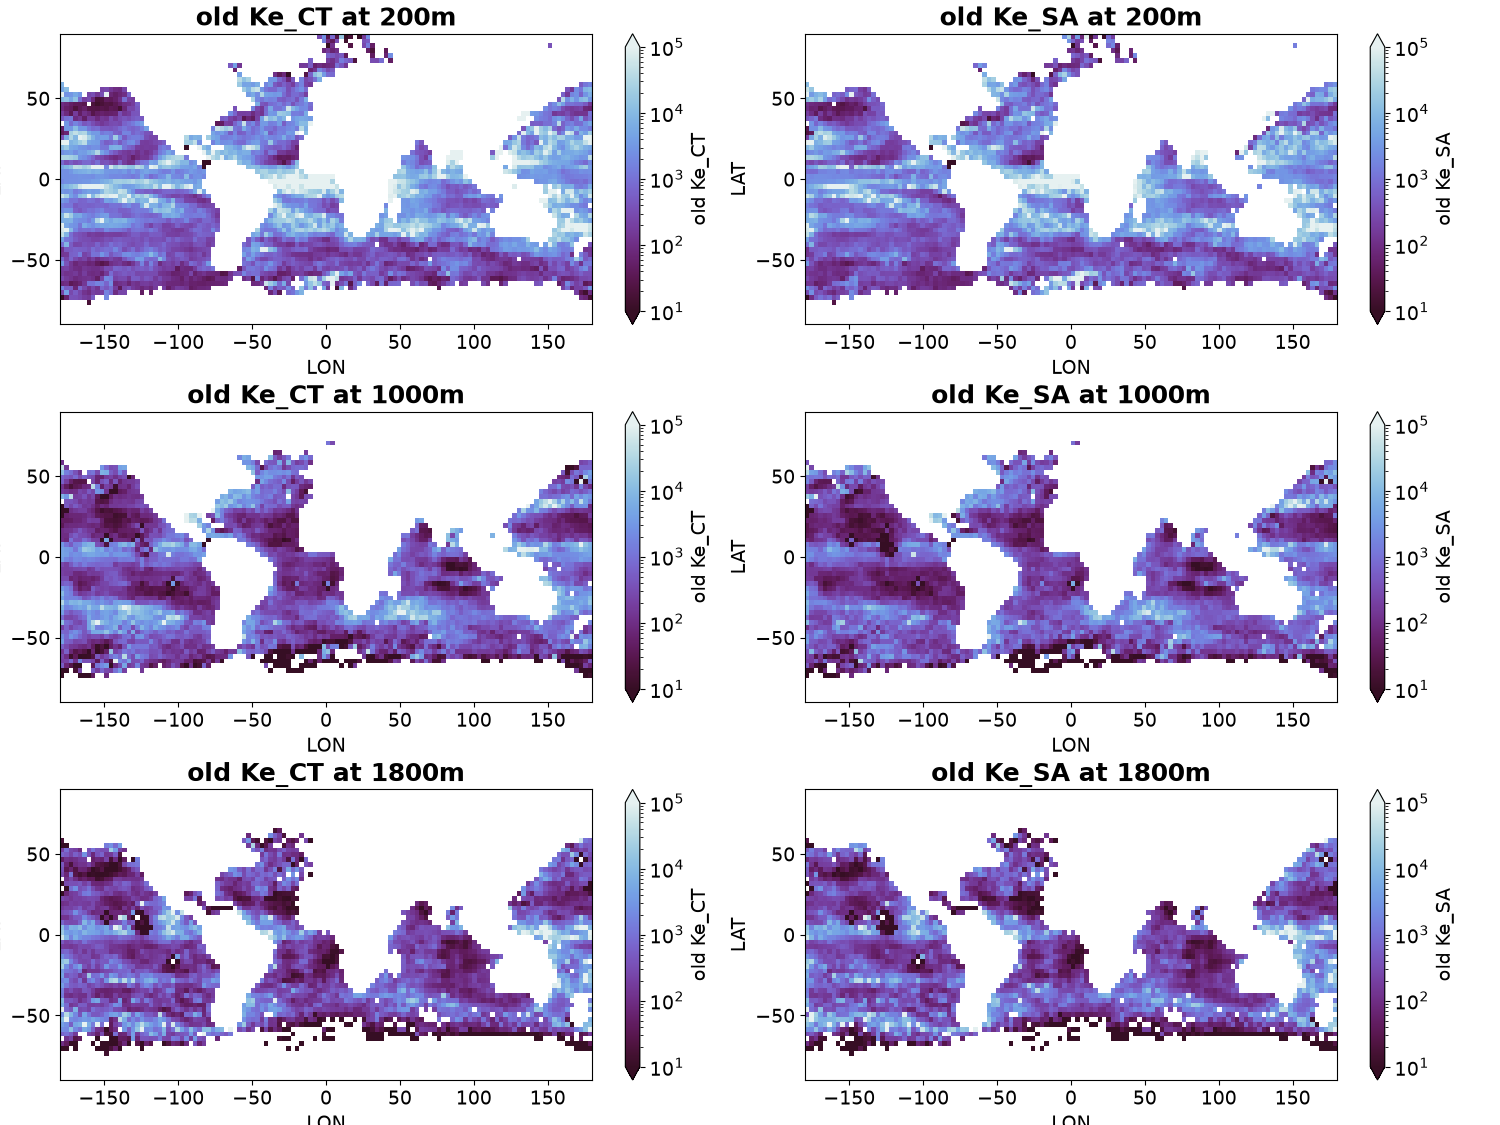

In [65]:
plt.figure(figsize=(15, 11.25))
d1, d2, d3 = 200, 1000, 1800

CT_vmin, CT_vmax = 1e1, 1e5
CT_norm = colors.LogNorm(vmin=float(CT_vmin), vmax=float(CT_vmax))
SA_vmin, SA_vmax = 1e1, 1e5
SA_norm = colors.LogNorm(vmin=float(SA_vmin), vmax=float(SA_vmax))

CT_var, CT_title = ds_pbar_grid.K_e_CT, 'old Ke_CT'
SA_var, SA_title = ds_pbar_grid.K_e_SA, 'old Ke_SA'

plt.subplot(321)
CT_var.sel(PRESSURE_mean=d1, method='nearest').plot(
    x='LON', y='LAT', norm=CT_norm, cmap=cmo.dense_r,
    cbar_kwargs={'label': CT_title}
)
plt.title('{} at {}m'.format(CT_title, d1))

plt.subplot(322)
SA_var.sel(PRESSURE_mean=d1, method='nearest').plot(
    x='LON', y='LAT', norm=SA_norm, cmap=cmo.dense_r,
    cbar_kwargs={'label': SA_title}
)
plt.title('{} at {}m'.format(SA_title, d1))

plt.subplot(323)
CT_var.sel(PRESSURE_mean=d2, method='nearest').plot(
    x='LON', y='LAT', norm=CT_norm, cmap=cmo.dense_r,
    cbar_kwargs={'label': CT_title}
)
plt.title('{} at {}m'.format(CT_title, d2))

plt.subplot(324)
SA_var.sel(PRESSURE_mean=d2, method='nearest').plot(
    x='LON', y='LAT', norm=SA_norm, cmap=cmo.dense_r,
    cbar_kwargs={'label': SA_title}
)
plt.title('{} at {}m'.format(SA_title, d2))

plt.subplot(325)
CT_var.sel(PRESSURE_mean=d3, method='nearest').plot(
    x='LON', y='LAT', norm=CT_norm, cmap=cmo.dense_r,
    cbar_kwargs={'label': CT_title}
)
plt.title('{} at {}m'.format(CT_title, d3))

plt.subplot(326)
SA_var.sel(PRESSURE_mean=d3, method='nearest').plot(
    x='LON', y='LAT', norm=SA_norm, cmap=cmo.dense_r,
    cbar_kwargs={'label': SA_title}
)
plt.title('{} at {}m'.format(SA_title, d3))

plt.subplots_adjust(left=0.04, right=0.98, bottom=0.04, top=0.97, wspace=0.12, hspace=0.3)
plt.show()

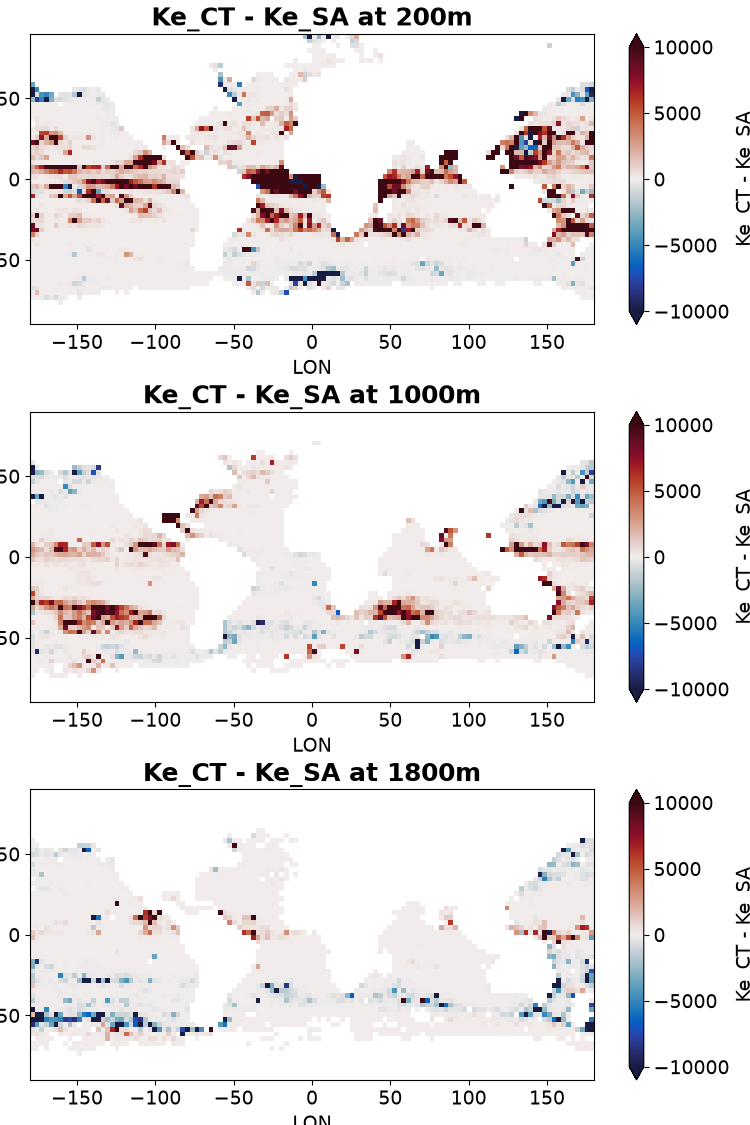

In [69]:
plt.figure(figsize=(7.5, 11.25))
d1, d2, d3 = 200, 1000, 1800

Ke_diff, title = ds_pbar_grid.K_e_CT - ds_pbar_grid.K_e_SA, 'Ke_CT - Ke_SA'

plt.subplot(311)
Ke_diff.sel(PRESSURE_mean=d1, method='nearest').plot(
    x='LON', y='LAT', vmin=-1e4, vmax=1e4, cmap=cmo.balance, center=0,
    cbar_kwargs={'label': title}
)
plt.title('{} at {}m'.format(title, d1))

plt.subplot(312)
Ke_diff.sel(PRESSURE_mean=d2, method='nearest').plot(
    x='LON', y='LAT', vmin=-1e4, vmax=1e4, cmap=cmo.balance, center=0,
    cbar_kwargs={'label': title}
)
plt.title('{} at {}m'.format(title, d2))

plt.subplot(313)
Ke_diff.sel(PRESSURE_mean=d3, method='nearest').plot(
    x='LON', y='LAT', vmin=-1e4, vmax=1e4
    , cmap=cmo.balance, center=0,
    cbar_kwargs={'label': title}
)
plt.title('{} at {}m'.format(title, d3))

plt.subplots_adjust(left=0.04, right=0.98, bottom=0.04, top=0.97, wspace=0.12, hspace=0.3)
plt.show()